# Lecture 9 — Direct Method II: Multiple Shooting

Notebook 01 ended with single shooting's two weaknesses: **fully coupled
Jacobian rows** (every control node influences every downstream constraint,
with no structure for the optimizer to exploit), and **sensitivities that grow
with the trajectory length**. Multiple shooting attacks both by cutting the
trajectory into independently integrated arcs.

**Roadmap**

1. **The idea** — arcs, extra variables, continuity defects
2. **Brachistochrone, multiply shot** — watching the defects close, and what
   happens to the Jacobian
3. **The switching-time formulation** — two variable-length phases for the
   minimum-time double integrator, with the control switch *at* the phase
   boundary
4. **A realistic interceptor** — Bryson's supersonic minimum-time climb by
   multiple shooting: tabulated aero/propulsion and path constraints
5. **Capstone** — a single-stage-to-orbit launch under (single) shooting

## 1. From one shot to many

Single shooting's constraint Jacobian chains sensitivities through the whole
trajectory: with the state-transition matrix
$\Phi(t_b, t_a) = \partial x(t_b) / \partial x(t_a)$,

$$
\frac{\partial x(t_f)}{\partial z} \;\sim\;
\Phi(t_f, t_{M-1}) \cdots \Phi(t_2, t_1)\,\Phi(t_1, t_0),
$$

For long trajectories, and especially for unstable dynamics, this product can
grow or decay exponentially. The resulting scale separation makes the
constraint Jacobian ill-conditioned: a small change in an early control
parameter may produce an enormous (or vanishingly small) change in the final
state.

**Multiple shooting** splits $[t_0, t_f]$ into $M$ arcs and makes the initial
state of each arc, $s_i$, a design variable. Each arc is integrated
*independently* — sensitivities only propagate across one arc — and the arcs
are stitched together by **continuity defect constraints**:

$$
d_i \;=\; x\big(t_{i+1}^-;\, s_i, U_i\big) - s_{i+1} \;=\; 0,
\qquad i = 1, \dots, M-1 .
$$

The price is a larger NLP (the $s_i$ and the $d_i$); the payoff is
shorter-horizon sensitivities that avoid a single long STM product, constraints
that each involve only *neighboring* arcs — i.e.
**sparsity** — and arcs that could even be integrated in parallel. During the
optimization the trajectory is **discontinuous**: the defects only close at
convergence. We can watch that happen.

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

warnings.filterwarnings('ignore', message='.*INF_BOUND.*')

import openmdao
import openmdao.api as om
from openmdao.utils.om_warnings import OpenMDAOWarning, DerivativesWarning

warnings.filterwarnings('ignore', category=OpenMDAOWarning)
warnings.filterwarnings('ignore', category=DerivativesWarning)

import dymos as dm
import ipywidgets as widgets
from IPython.display import display

from oclectures import (apply_style, describe_nlp, total_jacobian, plot_jacobian,
                        symbol_labels, quiet, redirect_outputs_to_tmp, COLORS)

apply_style()
redirect_outputs_to_tmp()  # keep OpenMDAO's problemN_out/ folders out of this directory
print(f'dymos {dm.__version__}, OpenMDAO {openmdao.__version__}')

dymos 1.15.1, OpenMDAO 3.45.1


---
## 2. The brachistochrone, multiply shot

Same problem and ODE component as notebook 01 (bead on a frictionless wire
from $(0, 10)$ to $(10, 5)$ m, control $\theta$ = velocity direction from the
downward vertical).

In [2]:
class BrachistochroneODE(om.ExplicitComponent):
    """Same dynamics as notebook 01."""

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('theta', val=np.zeros(nn), units='rad')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('ydot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')
        ar = np.arange(nn)
        self.declare_partials('xdot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('ydot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('vdot', 'theta', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        g = 9.80665
        v, theta = inputs['v'], inputs['theta']
        outputs['xdot'] = v * np.sin(theta)
        outputs['ydot'] = -v * np.cos(theta)
        outputs['vdot'] = g * np.cos(theta)

    def compute_partials(self, inputs, J):
        g = 9.80665
        v, theta = inputs['v'], inputs['theta']
        J['xdot', 'v'] = np.sin(theta)
        J['xdot', 'theta'] = v * np.cos(theta)
        J['ydot', 'v'] = -np.cos(theta)
        J['ydot', 'theta'] = v * np.sin(theta)
        J['vdot', 'theta'] = -g * np.sin(theta)


def brachistochrone_analytic(x0=0.0, y0=10.0, xf=10.0, yf=5.0, g=9.80665, n=200):
    def endpoint_eqs(unknowns):
        a, phi_f = unknowns
        return [a * (phi_f - np.sin(phi_f)) - (xf - x0),
                a * (1 - np.cos(phi_f)) - (y0 - yf)]
    a, phi_f = fsolve(endpoint_eqs, x0=[3.0, 2.0])
    phi = np.linspace(0, phi_f, n)
    return {'x': x0 + a * (phi - np.sin(phi)), 'y': y0 - a * (1 - np.cos(phi)),
            't': phi * np.sqrt(a / g), 'theta': phi / 2,
            'tf': phi_f * np.sqrt(a / g)}


ana = brachistochrone_analytic()

### Multiple shooting in dymos

We build the textbook formulation directly: **one shooting phase per arc**,
collected in a `dm.Trajectory`.

- Each arc is its own `ExplicitShooting` phase — the same transcription as
  notebook 01 (one segment, piecewise-linear $\theta$), with the states
  integrated by adaptive DOP853 from *that arc's own* initial state.
- For every arc after the first, `fix_initial=False` on time and states turns
  the arc's start time and initial state $(x, y, v)$ into **design
  variables** — these are the $s_i$.
- `traj.link_phases(...)` adds the **continuity defects** $d_i$ as
  constraints: time, the three states, and the control value must match where
  consecutive arcs meet. (Each arc's duration is also free — multiple
  shooting needn't keep the arcs equal.)

Nothing else changes relative to notebook 01: same ODE, same terminal
boundary constraints (now on the *last* arc), same objective.

(dymos also offers a compact route to multiple shooting that packs all the
arcs into a single phase — we will use it for the realistic problem in
section 4.)

In [3]:
def build_brach_multiple_shooting(num_arcs=4):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)

    traj = p.model.add_subsystem('traj', dm.Trajectory())

    phases = []
    for k in range(num_arcs):
        # Same transcription as notebook 01: piecewise-linear control, DOP853
        # states. The denser output grid only adds plot points along the
        # integrated arc; it changes nothing about the NLP.
        tx = dm.ExplicitShooting(
            grid=dm.GaussLobattoGrid(num_segments=1, nodes_per_seg=2),
            output_grid=dm.UniformGrid(num_segments=1, nodes_per_seg=15))
        phase = traj.add_phase(f'arc{k}', dm.Phase(ode_class=BrachistochroneODE,
                                                   transcription=tx))
        first = (k == 0)
        if first:  # arc 0 starts at the fixed initial condition
            phase.set_time_options(fix_initial=True,
                                   duration_bounds=(0.05, 5.0), units='s')
        else:      # every later arc: start time and initial state s_i are free
            phase.set_time_options(fix_initial=False, initial_bounds=(0.0, 10.0),
                                   duration_bounds=(0.05, 5.0), units='s')
        phase.add_state('x', fix_initial=first, rate_source='xdot', units='m')
        phase.add_state('y', fix_initial=first, rate_source='ydot', units='m')
        phase.add_state('v', fix_initial=first, rate_source='vdot', units='m/s')
        phase.add_control('theta', units='rad', lower=0.01, upper=3.0,
                          continuity=True, rate_continuity=False)
        phases.append(phase)

    # Terminal conditions live on the LAST arc only
    phases[-1].add_boundary_constraint('x', loc='final', equals=10.0)
    phases[-1].add_boundary_constraint('y', loc='final', equals=5.0)
    phases[-1].add_objective('time', loc='final')

    # The continuity defects d_i: time, states, and the control value must
    # match where consecutive arcs meet
    traj.link_phases(phases=[f'arc{k}' for k in range(num_arcs)],
                     vars=['time', 'x', 'y', 'v', 'theta'])

    p.setup()
    # Linear-ramp guesses: the arc initial states s_i start on straight lines
    # between the endpoints, so the integrated arcs will NOT match up at first.
    xg, yg = np.linspace(0, 10, num_arcs + 1), np.linspace(10, 5, num_arcs + 1)
    vg = np.linspace(0, 10, num_arcs + 1)
    thg = np.linspace(0.1, 0.8, num_arcs + 1)
    dt = 2.0 / num_arcs
    for k, phase in enumerate(phases):
        phase.set_time_val(initial=k * dt, duration=dt)
        phase.set_state_val('x', [xg[k], xg[k + 1]])
        phase.set_state_val('y', [yg[k], yg[k + 1]])
        phase.set_state_val('v', [vg[k], vg[k + 1]])
        phase.set_control_val('theta', [thg[k], thg[k + 1]])
    return p


def extract_arcs(p, num_arcs):
    """Return per-arc (t, x, y) from each arc phase's timeseries."""
    # .copy() matters: get_val returns views into the model's data vectors,
    # which the optimizer overwrites on the next run
    return [tuple(p.get_val(f'traj.arc{k}.timeseries.{v}')[:, 0].copy()
                  for v in ('time', 'x', 'y'))
            for k in range(num_arcs)]

### Watching the defects close

`run_model()` integrates every arc once from its current initial state — no
optimization. With the linear-ramp guesses, the arcs visibly **fail to connect**:
each starts from its guessed $s_i$ (filled dot) and ends somewhere else
(the defect $d_i$ is the gap to the next dot). After `run_driver()`, the
optimizer has closed every defect *and* met the terminal constraint.

In [4]:
NUM_ARCS = 4
p_ms = build_brach_multiple_shooting(NUM_ARCS)

p_ms.run_model()  # integrate each arc from its guess: defects wide open
arcs_before = extract_arcs(p_ms, NUM_ARCS)

t0 = time.perf_counter()
res = p_ms.run_driver()  # close the defects, satisfy the BCs, minimize tf
wall_ms = time.perf_counter() - t0
arcs_after = extract_arcs(p_ms, NUM_ARCS)

tf_ms = p_ms.get_val(f'traj.arc{NUM_ARCS - 1}.timeseries.time')[-1, 0]
print(f'multiple shooting: tf = {tf_ms:.6f} s (analytic {ana["tf"]:.6f} s), '
      f'wall {wall_ms:.1f} s, success={res.success}')

multiple shooting: tf = 1.801610 s (analytic 1.801603 s), wall 2.5 s, success=True


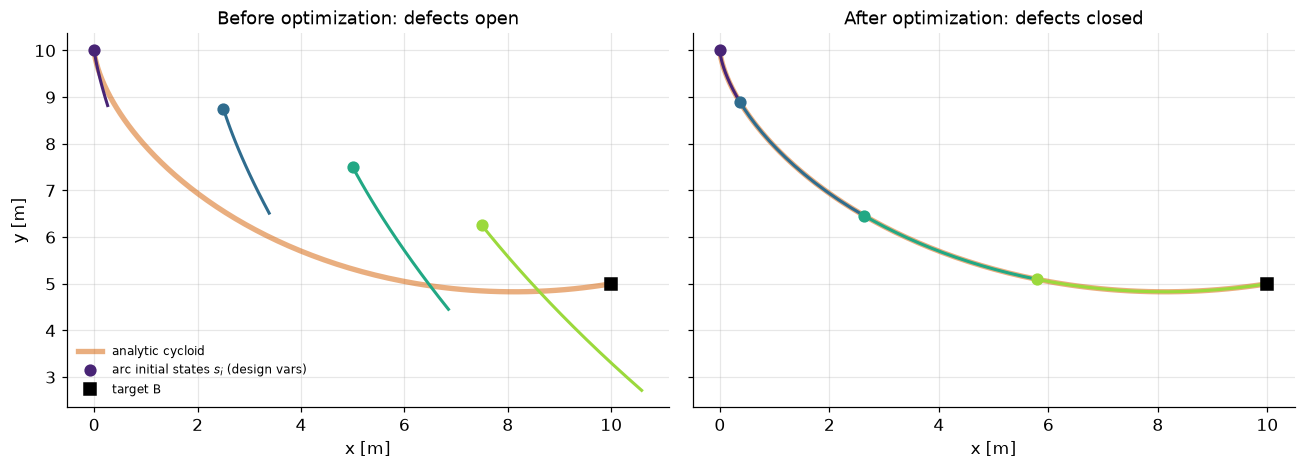

In [5]:
arc_colors = plt.cm.viridis(np.linspace(0.1, 0.85, NUM_ARCS))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, arcs, title in [(axes[0], arcs_before, 'Before optimization: defects open'),
                        (axes[1], arcs_after, 'After optimization: defects closed')]:
    ax.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.5,
            label='analytic cycloid')
    for k, (t, x, y) in enumerate(arcs):
        ax.plot(x, y, '-', color=arc_colors[k], lw=2)
        ax.plot(x[0], y[0], 'o', color=arc_colors[k], ms=7, zorder=5,
                label='arc initial states $s_i$ (design vars)' if k == 0 else None)
    ax.plot(10, 5, 's', ms=8, color='k', label='target B')
    ax.set_xlabel('x [m]'); ax.set_title(title)
axes[0].set_ylabel('y [m]')
axes[0].legend(fontsize=8, loc='lower left')
fig.tight_layout()

### The NLP, grown but structured

Compare with notebook 01's single-shooting NLP (17 variables, 9 constraints):
every interior arc now contributes its start time and initial state
$(x, y, v)$ — the $s_i$ — as design variables, and five linkage defects
(time, $x$, $y$, $v$, $\theta$) as constraints. Every piece is visible by
name:

In [6]:
describe_nlp(p_ms, title=f'Brachistochrone, multiple shooting ({NUM_ARCS} arcs)');

=== Brachistochrone, multiple shooting (4 arcs) ===

Design variables (z):
  arc0.t_duration                            size    1
  arc0.theta                                 size    2
  arc1.t_initial                             size    1
  arc1.t_duration                            size    1
  arc1.theta                                 size    2
  arc1.initial_x                             size    1
  arc1.initial_y                             size    1
  arc1.initial_v                             size    1
  arc2.t_initial                             size    1
  arc2.t_duration                            size    1
  arc2.theta                                 size    2
  arc2.initial_x                             size    1
  arc2.initial_y                             size    1
  arc2.initial_v                             size    1
  arc3.t_initial                             size    1
  arc3.t_duration                            size    1
  arc3.theta                                 

And the Jacobian: a defect $d_i$ depends only on arc $i$'s initial state and
controls (through one arc of integration) and on $s_{i+1}$ (directly) —
nothing else. Single shooting's fully coupled rows break into **staircase
blocks**. For comparison we re-solve the single-shooting version from
notebook 01 alongside.

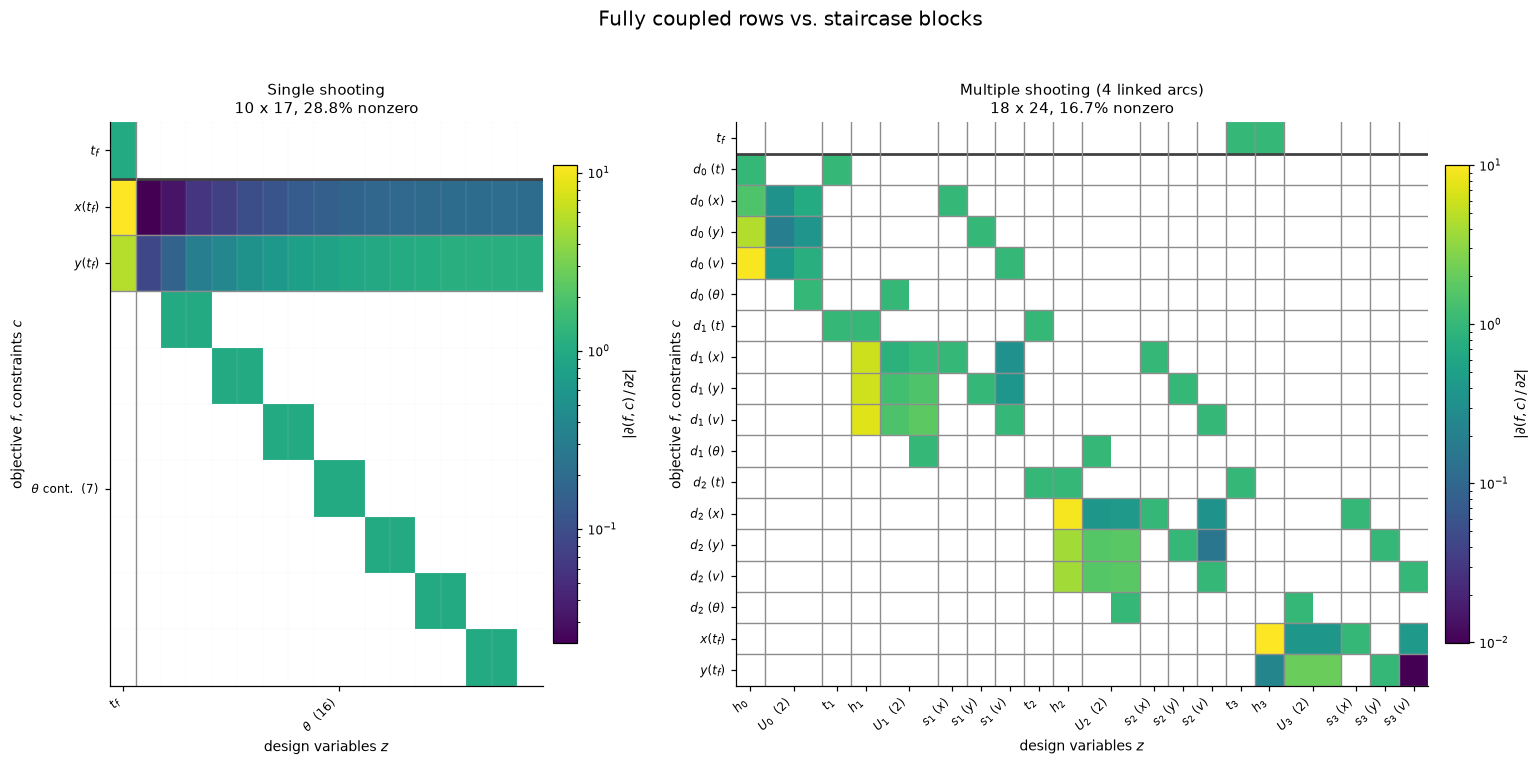

In [7]:
def build_brach_single_shooting(num_segments=8, nodes_per_seg=2):
    """Notebook 01's shooting problem, condensed: piecewise-linear control,
    value continuity only (rate continuity would weld the linear segments
    into one straight line)."""
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)
    grid = dm.GaussLobattoGrid(num_segments=num_segments, nodes_per_seg=nodes_per_seg)
    phase = dm.Phase(ode_class=BrachistochroneODE,
                     transcription=dm.ExplicitShooting(grid=grid))
    p.model.add_subsystem('phase0', phase)
    phase.set_time_options(fix_initial=True, duration_bounds=(0.5, 10.0), units='s')
    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    phase.add_state('y', fix_initial=True, rate_source='ydot', units='m')
    phase.add_state('v', fix_initial=True, rate_source='vdot', units='m/s')
    phase.add_control('theta', units='rad', lower=0.01, upper=3.0,
                      continuity=True, rate_continuity=False)
    phase.add_boundary_constraint('x', loc='final', equals=10.0)
    phase.add_boundary_constraint('y', loc='final', equals=5.0)
    phase.add_objective('time', loc='final')
    p.setup()
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, 10])
    phase.set_state_val('y', [10, 5])
    phase.set_state_val('v', [0, 10])
    phase.set_control_val('theta', [0.1, 0.8])
    return p


p_ss = build_brach_single_shooting()
with quiet():
    p_ss.run_driver()

J_ss, of_ss, wrt_ss = total_jacobian(p_ss)
J_ms, of_ms, wrt_ms = total_jacobian(p_ms)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6.8),
                               gridspec_kw={'width_ratios': [1, 1.6]})
plot_jacobian(J_ss, symbol_labels(of_ss), symbol_labels(wrt_ss), ax=ax1, title='Single shooting')
plot_jacobian(J_ms, symbol_labels(of_ms), symbol_labels(wrt_ms), ax=ax2,
              title=f'Multiple shooting ({NUM_ARCS} linked arcs)')
fig.suptitle('Fully coupled rows vs. staircase blocks', y=1.02)
fig.tight_layout()

Reading the right panel: each defect row $d_i$ couples one arc's variables to the
*next* arc's initial state — a banded staircase — and the terminal boundary
constraints touch only the *last* arc's variables. More arcs means more (but
smaller and more local) blocks. Collocation uses the same localization idea,
but replaces per-arc integration by polynomial defect equations. Hold that
thought for Lecture 10.

---
## 3. Arcs with a purpose: the switching-time formulation

Notebook 01 left a loose end. For the minimum-time double integrator (started
at $v_0 = 0.5$ m/s so the switch sits at $t_s/t_f \approx 35\%$ — where no
uniform grid is likely to put a boundary), the final-time error was governed
above all by **the distance from the nearest segment boundary to the switch
time**. Refinement shrinks that distance but never zeroes it, because the
switch time is unknown a priori. Multiple shooting offers the clean escape —
*make the boundary a design variable and let the optimizer put it on the
switch*:

- **two shooting phases** of *variable duration* (the boundary between them is
  a design variable — it will become the switch time $t_s$);
- in each phase, the control is a single **constant parameter** $u_i$ bounded
  by $|u_i| \le 1$ (the optimizer may pick any value — bang-bang is not
  assumed);
- **linkage constraints** glue the phases: time, $x$ and $v$ must be
  continuous across the boundary — the same linkage defects as section 2,
  except that here the *location* of the arc boundary is the entire point.

What we *do* assume is the **switching structure**: one switch, hence two
arcs. Where that knowledge comes from — Pontryagin's minimum principle — is
the subject of Lecture 11. Given the structure, the optimizer only has to
place the boundary.

In [8]:
class DoubleIntegratorODE(om.ExplicitComponent):

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('u', val=np.zeros(nn), units='m/s**2')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')
        ar = np.arange(nn)
        self.declare_partials('xdot', 'v', rows=ar, cols=ar, val=1.0)
        self.declare_partials('vdot', 'u', rows=ar, cols=ar, val=1.0)

    def compute(self, inputs, outputs):
        outputs['xdot'] = inputs['v']
        outputs['vdot'] = inputs['u']


V0, D = 0.5, 1.0  # same problem as notebook 01: initial velocity, distance


def analytic_double_integrator(v0=V0, d=D, n=400):
    """Same as notebook 01: min-time transfer from (x, v) = (0, v0) to (d, 0)."""
    ts = np.sqrt(d + v0**2 / 2) - v0
    tf = 2 * np.sqrt(d + v0**2 / 2) - v0
    t = np.linspace(0, tf, n)
    return {'t': t,
            'u': np.where(t < ts, 1.0, -1.0),
            'v': np.where(t < ts, v0 + t, tf - t),
            'x': np.where(t < ts, v0 * t + 0.5 * t**2, d - 0.5 * (tf - t)**2),
            'ts': ts, 'tf': tf}


ana_di = analytic_double_integrator()
print(f"analytic: switch at t_s = {ana_di['ts']:.6f} s "
      f"({ana_di['ts'] / ana_di['tf']:.1%} of t_f = {ana_di['tf']:.6f} s)")

analytic: switch at t_s = 0.560660 s (34.6% of t_f = 1.621320 s)


In [9]:
def build_two_phase_di():
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)
    p.driver.options['disp'] = False

    traj = p.model.add_subsystem('traj', dm.Trajectory())

    def make_phase():
        grid = dm.GaussLobattoGrid(num_segments=1, nodes_per_seg=3)
        return dm.Phase(ode_class=DoubleIntegratorODE,
                        transcription=dm.ExplicitShooting(grid=grid))

    accel = traj.add_phase('accel', make_phase())
    accel.set_time_options(fix_initial=True, duration_bounds=(0.05, 5.0), units='s')
    accel.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    accel.add_state('v', fix_initial=True, rate_source='vdot', units='m/s')
    # One constant control level for the whole arc, free within [-1, 1]
    accel.add_parameter('u', units='m/s**2', opt=True, lower=-1.0, upper=1.0)

    brake = traj.add_phase('brake', make_phase())
    brake.set_time_options(fix_initial=False, initial_bounds=(0.05, 5.0),
                           duration_bounds=(0.05, 5.0), units='s')
    brake.add_state('x', fix_initial=False, rate_source='xdot', units='m')
    brake.add_state('v', fix_initial=False, rate_source='vdot', units='m/s')
    brake.add_parameter('u', units='m/s**2', opt=True, lower=-1.0, upper=1.0)

    brake.add_boundary_constraint('x', loc='final', equals=D)
    brake.add_boundary_constraint('v', loc='final', equals=0.0)
    brake.add_objective('time', loc='final')

    # Continuity defects between the phases: time, x, v
    traj.link_phases(phases=['accel', 'brake'], vars=['time', 'x', 'v'])

    p.setup()
    accel.set_time_val(initial=0.0, duration=0.8)
    accel.set_state_val('x', [0, 0.45])
    accel.set_state_val('v', [V0, 1.0])
    accel.set_parameter_val('u', 0.5)
    brake.set_time_val(initial=0.8, duration=0.8)
    brake.set_state_val('x', [0.45, D])
    brake.set_state_val('v', [1.0, 0.0])
    brake.set_parameter_val('u', -0.5)
    return p


p2 = build_two_phase_di()
t0 = time.perf_counter()
res = p2.run_driver()
wall2 = time.perf_counter() - t0

t_switch = p2.get_val('traj.accel.timeseries.time')[-1, 0]
tf2 = p2.get_val('traj.brake.timeseries.time')[-1, 0]
u1 = p2.get_val('traj.accel.parameter_vals:u').ravel()[0]
u2 = p2.get_val('traj.brake.parameter_vals:u').ravel()[0]

print(f'success={res.success}, wall {wall2:.1f} s')
print(f"switch time  t_s = {t_switch:.10f}   (analytic {ana_di['ts']:.10f})")
print(f"final time   t_f = {tf2:.10f}   (analytic {ana_di['tf']:.10f})")
print(f'control      u_1 = {u1:+.6f}, u_2 = {u2:+.6f}   (analytic +1, -1)')

success=True, wall 0.2 s
switch time  t_s = 0.5606601718   (analytic 0.5606601718)
final time   t_f = 1.6213203436   (analytic 1.6213203436)
control      u_1 = +1.000000, u_2 = -1.000000   (analytic +1, -1)


Machine precision, from an NLP small enough to read in one breath — no grid
refinement, no smearing. The control levels saturated at $\pm 1$ on their own;
only the switching *structure* was assumed.

In [10]:
describe_nlp(p2, title='Double integrator, two linked shooting phases');

=== Double integrator, two linked shooting phases ===

Design variables (z):
  accel.t_duration                           size    1
  accel.parameters:u                         size    1
  brake.t_initial                            size    1
  brake.t_duration                           size    1
  brake.parameters:u                         size    1
  brake.initial_x                            size    1
  brake.initial_v                            size    1

Constraints (c(z)):
  defect accel|brake: time                   size    1
  defect accel|brake: x                      size    1
  defect accel|brake: v                      size    1
  brake.x[final]                             size    1
  brake.v[final]                             size    1

Objective (f(z)):
  brake.t

--> NLP with 7 variables and 5 constraints


Seven variables: two durations (the second phase's start time is tied to the
first's end through a linkage), two control levels, and the brake arc's free
initial state $(x, v)$ — plus five constraints: three linkage defects and two
terminal conditions. Every piece of the multiple-shooting formulation from
section 1 is visible by name.

### Structure beats refinement

The slider sweeps notebook 01's single-phase solutions over the number of
segments; the two-phase solution and the analytic optimum are fixed overlays.
Even at 16 segments the fixed grid is limited by how close a boundary happens
to fall to $t_s \approx 0.56$ s — the seven-variable two-phase NLP is exact at
any resolution.

In [11]:
def build_single_phase_di(num_segments=5, nodes_per_seg=2):
    """Notebook 01's single-phase min-time double integrator, condensed
    (piecewise-linear control with jumps allowed at segment boundaries)."""
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=400, tol=1e-9)
    p.driver.options['disp'] = False
    grid = dm.GaussLobattoGrid(num_segments=num_segments, nodes_per_seg=nodes_per_seg)
    phase = dm.Phase(ode_class=DoubleIntegratorODE,
                     transcription=dm.ExplicitShooting(grid=grid))
    p.model.add_subsystem('phase0', phase)
    phase.set_time_options(fix_initial=True, duration_bounds=(0.3, 10.0), units='s')
    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    phase.add_state('v', fix_initial=True, rate_source='vdot', units='m/s')
    phase.add_control('u', units='m/s**2', lower=-1.0, upper=1.0,
                      continuity=False, rate_continuity=False)
    phase.add_boundary_constraint('x', loc='final', equals=D)
    phase.add_boundary_constraint('v', loc='final', equals=0.0)
    phase.add_objective('time', loc='final')
    p.setup()
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, D])
    phase.set_state_val('v', [V0, 0])
    phase.set_control_val('u', [1.0, -1.0])
    return p


single_sweep = {}
for ns in [2, 4, 8, 16]:
    p = build_single_phase_di(ns)
    with quiet():
        r = p.run_driver()
    # Plot from the timeseries grid nodes: with a piecewise-linear control,
    # the exact solution dymos used is the polyline through them. (simulate()
    # would re-interpolate the control as continuous and smear its jumps.)
    single_sweep[ns] = {
        'tf': p.get_val('phase0.timeseries.time')[-1, 0],
        'nodes': {k: p.get_val(f'phase0.timeseries.{k}')[:, 0].copy()
                  for k in ('time', 'x', 'v', 'u')}}
    print(f'single phase, {ns:2d} segments: tf = {single_sweep[ns]["tf"]:.6f} s')

# Dense view of the two-phase solution: per phase, u is constant
with quiet():
    sim2 = p2.model.traj.simulate(times_per_seg=20)
two_phase = {}
for name, u_val in [('accel', u1), ('brake', u2)]:
    two_phase[name] = {k: sim2.get_val(f'traj.{name}.timeseries.{k}')[:, 0]
                       for k in ('time', 'x', 'v')}
    two_phase[name]['u'] = np.full_like(two_phase[name]['time'], u_val)

single phase,  2 segments: tf = 1.694254 s
single phase,  4 segments: tf = 1.638325 s
single phase,  8 segments: tf = 1.625229 s
single phase, 16 segments: tf = 1.622227 s


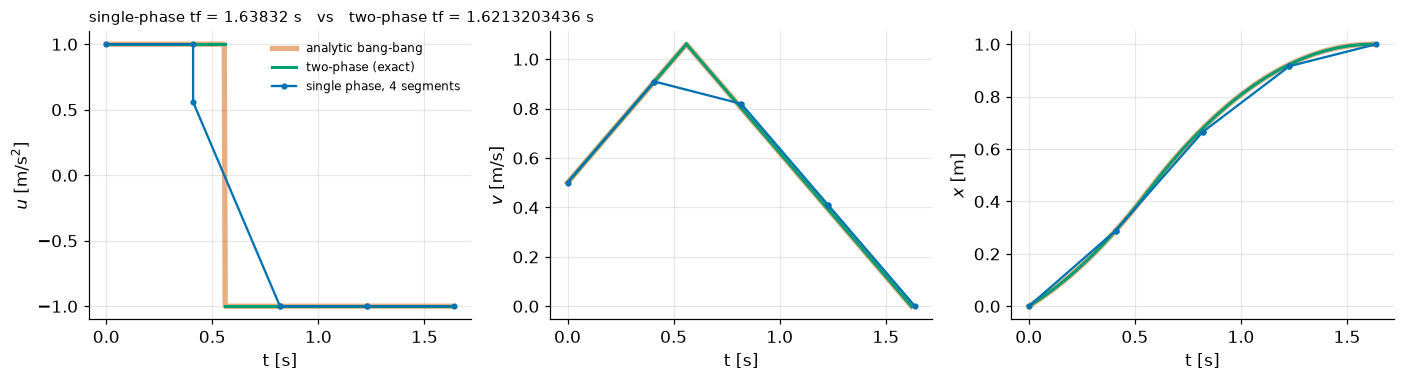

interactive(children=(SelectionSlider(description='segments', index=1, options=(2, 4, 8, 16), value=4), Output…

In [12]:
def plot_di_comparison(ns):
    sol = single_sweep[ns]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, key, ylabel in zip(axes, ('u', 'v', 'x'),
                               (r'$u$ [m/s$^2$]', r'$v$ [m/s]', r'$x$ [m]')):
        ax.plot(ana_di['t'], ana_di[key], color=COLORS['analytic'], lw=3.5,
                alpha=0.5, label='analytic bang-bang')
        for name in ('accel', 'brake'):
            d = two_phase[name]
            ax.plot(d['time'], d[key], color=COLORS['secondary'], lw=2,
                    label='two-phase (exact)' if name == 'accel' else None)
        d = sol['nodes']
        ax.plot(d['time'], d[key], 'o-', ms=3, lw=1.5, color=COLORS['dymos'],
                label=f'single phase, {ns} segments')
        ax.set_xlabel('t [s]'); ax.set_ylabel(ylabel)
    axes[0].legend(fontsize=8)
    axes[0].set_title(
        f'single-phase tf = {sol["tf"]:.5f} s   vs   two-phase tf = {tf2:.10f} s',
        loc='left', fontsize=10)
    fig.tight_layout()
    return fig


seg_slider = widgets.SelectionSlider(options=[2, 4, 8, 16], value=4,
                                     description='segments')

@widgets.interact(ns=seg_slider)
def show_comparison(ns):
    plot_di_comparison(ns)
    plt.show()

---
## 4. A realistic interceptor: minimum time to climb

Bryson's classic supersonic interceptor problem, on an F-4-class aircraft:
starting just above sea level at Mach 0.4, reach $h = 20$ km at Mach 1.0 in
level flight ($\gamma = 0$) in minimum time,

$$
\dot{r} = v\cos\gamma, \quad \dot{h} = v\sin\gamma, \quad
\dot{v} = \frac{T\cos\alpha - D}{m} - g\sin\gamma, \quad
\dot{\gamma} = \frac{T\sin\alpha + L}{m v} - \frac{g\cos\gamma}{v}, \quad
\dot{m} = -\frac{T}{g_0 I_{sp}},
$$

with angle of attack $\alpha$ as the control and **path constraints**
$100\,\mathrm{m} \le h \le 20\,\mathrm{km}$ and $0.1 \le M \le 1.8$ enforced
at the transcription's discrete path-constraint nodes — our first inequality
constraints on the *path* rather than the endpoints. A dense check or mesh
refinement is needed to rule out between-node violations.

The model is not a toy: lift/drag coefficient tables in Mach, Bryson's thrust
table in (Mach, altitude), and the 1976 standard atmosphere. dymos ships this
ODE as a packaged example with analytic partials, so we simply import it —
ODE components are reusable building blocks, exactly like the hand-written
ones in this notebook.

We solve it by **multiple shooting** with 12 arcs — but declaring twelve
linked phases of a five-state aircraft gets verbose, so here we use dymos's
**compact route**, which packs all the arcs into a single phase: a `Radau`
transcription with

- `solve_segments='forward'` — a nested Newton solver converges each
  segment's dynamics at every evaluation, so each segment becomes an
  independently integrated arc (an *implicit* one-step integration whose
  accuracy is set by `order`, rather than section 2's adaptive DOP853);
- `compressed=False` — segments don't share boundary nodes, so each arc's
  initial state is its own design variable, and the continuity defects are
  added automatically.

The NLP has exactly section 2's structure — $s_i$, defects, staircase — with
one phase to declare instead of twelve. This is where the machinery earns its
keep on a real problem: every SLSQP iterate implicitly integrates twelve
*short* arcs instead of one long, sensitive trajectory, and the junction
states give the optimizer direct handles on the flight profile.

In [13]:
from dymos.examples.min_time_climb.min_time_climb_ode import MinTimeClimbODE


def build_min_time_climb(num_arcs=12, order=3):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=500, tol=1e-6)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)

    tx = dm.Radau(num_segments=num_arcs, order=order,
                  compressed=False, solve_segments='forward')
    phase = dm.Phase(ode_class=MinTimeClimbODE, transcription=tx)
    p.model.add_subsystem('phase0', phase)

    phase.set_time_options(fix_initial=True, duration_bounds=(50, 400),
                           duration_ref=100.0, units='s')

    phase.add_state('r', fix_initial=True, lower=0, upper=1.0e6,
                    ref=1.0e3, rate_source='flight_dynamics.r_dot', units='m')
    phase.add_state('h', fix_initial=True, lower=0, upper=20000.0,
                    ref=1.0e2, rate_source='flight_dynamics.h_dot', units='m')
    phase.add_state('v', fix_initial=True, lower=10.0,
                    ref=1.0e2, rate_source='flight_dynamics.v_dot', units='m/s')
    phase.add_state('gam', fix_initial=True, lower=-1.5, upper=1.5,
                    ref=1.0, rate_source='flight_dynamics.gam_dot', units='rad')
    phase.add_state('m', fix_initial=True, lower=10.0, upper=1.0e5,
                    ref=1.0e3, rate_source='prop.m_dot', units='kg')

    phase.add_control('alpha', units='deg', lower=-8.0, upper=8.0, scaler=1.0,
                      rate_continuity=True, rate_continuity_scaler=100.0,
                      rate2_continuity=False)

    # Fixed aircraft parameters, forwarded into the ODE
    phase.add_parameter('S', val=49.2386, units='m**2', opt=False, targets=['S'])
    phase.add_parameter('Isp', val=1600.0, units='s', opt=False, targets=['Isp'])
    phase.add_parameter('throttle', val=1.0, opt=False, targets=['throttle'])

    phase.add_boundary_constraint('h', loc='final', equals=20000, scaler=1.0e-3)
    phase.add_boundary_constraint('aero.mach', loc='final', equals=1.0)
    phase.add_boundary_constraint('gam', loc='final', equals=0.0)

    # Path inequalities, enforced at the transcription's path-constraint nodes
    phase.add_path_constraint('h', lower=100.0, upper=20000, ref=20000)
    phase.add_path_constraint('aero.mach', lower=0.1, upper=1.8)

    phase.add_objective('time', loc='final', ref=100.0)

    p.setup()

    phase.set_time_val(initial=0.0, duration=300.0)
    phase.set_state_val('r', [0.0, 111319.54])
    phase.set_state_val('h', [100.0, 20000.0])
    phase.set_state_val('v', [135.964, 283.159])
    phase.set_state_val('gam', [0.0, 0.0])
    phase.set_state_val('m', [19030.468, 16841.431])
    phase.set_control_val('alpha', [0.0, 0.0])
    return p


p_mtc = build_min_time_climb()
t0 = time.perf_counter()
res = p_mtc.run_driver()
wall_mtc = time.perf_counter() - t0

tf_mtc = p_mtc.get_val('phase0.timeseries.time')[-1, 0]
print(f'success={res.success}, wall {wall_mtc:.0f} s')
print(f'tf = {tf_mtc:.2f} s  (published collocation result: ~321 s; the gap '
      f'is discretization -- 12 cubic arcs)')
print(f"final: h = {p_mtc.get_val('phase0.timeseries.h')[-1, 0]:.0f} m, "
      f"Mach = {p_mtc.get_val('phase0.timeseries.mach')[-1, 0]:.4f}, "
      f"gam = {p_mtc.get_val('phase0.timeseries.gam')[-1, 0]:.1e} rad")

success=True, wall 19 s
tf = 325.53 s  (published collocation result: ~321 s; the gap is discretization -- 12 cubic arcs)
final: h = 20000 m, Mach = 1.0000, gam = -1.4e-13 rad


In [14]:
describe_nlp(p_mtc, title='Min-time climb, multiple shooting (12 arcs)');

=== Min-time climb, multiple shooting (12 arcs) ===

Design variables (z):
  t_duration                                 size    1
  r                                          size   11
  h                                          size   11
  v                                          size   11
  gam                                        size   11
  m                                          size   11
  alpha                                      size   36

Constraints (c(z)):
  h[final]                                   size    1
  mach[final]                                size    1
  gam[final]                                 size    1
  h[path]                                    size   47
  mach[path]                                 size   47
  cont.: r                                   size   11
  cont.: h                                   size   11
  cont.: v                                   size   11
  cont.: gam                                 size   11
  cont.: m              

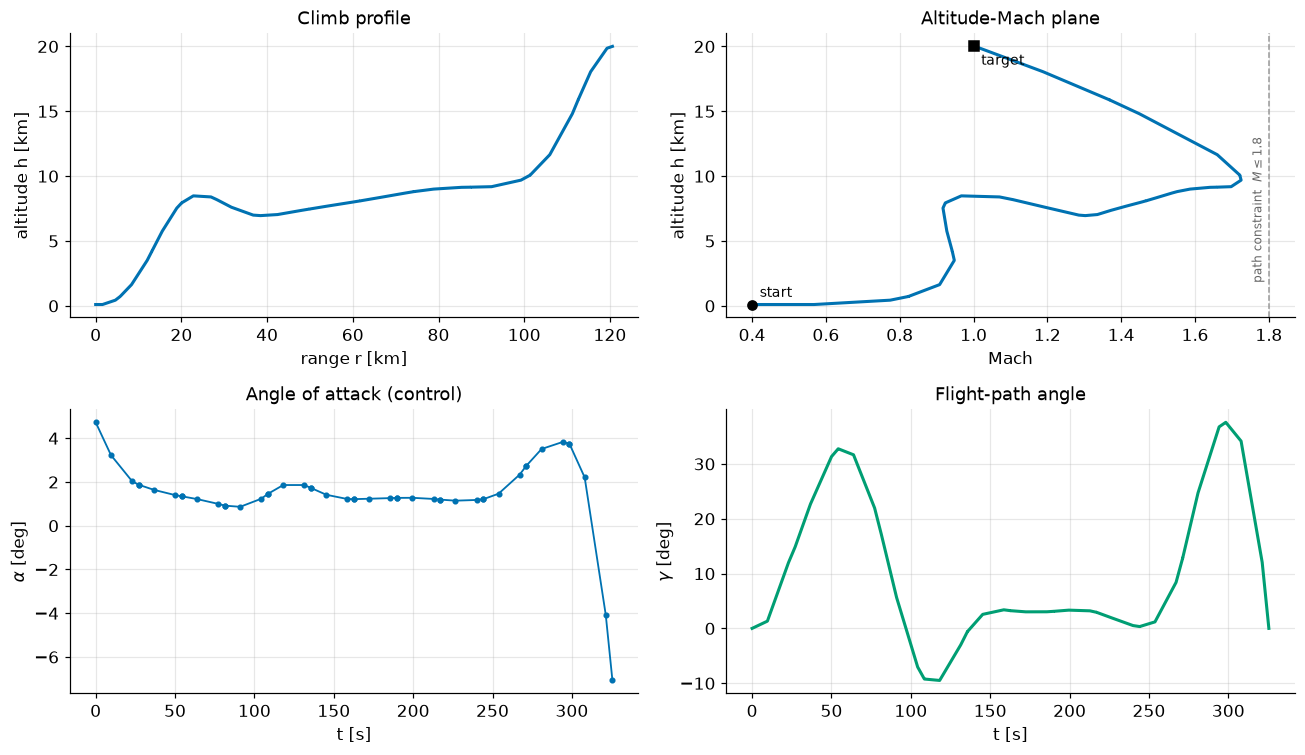

In [15]:
mtc = {k: p_mtc.get_val(f'phase0.timeseries.{k}')[:, 0].copy()
       for k in ('time', 'r', 'h', 'v', 'gam', 'alpha', 'mach')}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

ax = axes[0, 0]
ax.plot(mtc['r'] / 1e3, mtc['h'] / 1e3, color=COLORS['dymos'])
ax.set_xlabel('range r [km]'); ax.set_ylabel('altitude h [km]')
ax.set_title('Climb profile')

ax = axes[0, 1]
ax.plot(mtc['mach'], mtc['h'] / 1e3, color=COLORS['dymos'])
ax.axvline(1.8, color='0.6', ls='--', lw=1)
ax.text(1.79, 2.0, 'path constraint  $M \\leq 1.8$', rotation=90,
        fontsize=8, color='0.4', ha='right')
ax.plot(mtc['mach'][0], mtc['h'][0] / 1e3, 'o', color='k')
ax.annotate('start', (mtc['mach'][0], mtc['h'][0] / 1e3),
            xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.plot(1.0, 20, 's', color='k')
ax.annotate('target', (1.0, 20), xytext=(5, -12),
            textcoords='offset points', fontsize=9)
ax.set_xlabel('Mach'); ax.set_ylabel('altitude h [km]')
ax.set_title('Altitude-Mach plane')

ax = axes[1, 0]
ax.plot(mtc['time'], mtc['alpha'], 'o-', ms=3, lw=1.2, color=COLORS['dymos'])
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\alpha$ [deg]')
ax.set_title('Angle of attack (control)')

ax = axes[1, 1]
ax.plot(mtc['time'], np.degrees(mtc['gam']), color=COLORS['secondary'])
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\gamma$ [deg]')
ax.set_title('Flight-path angle')
fig.tight_layout()

The altitude–Mach plane shows the celebrated structure of this problem — a
**Rutowski energy climb**: the interceptor first climbs subsonically to about
8.5 km, then *dives* — deliberately losing altitude to punch through the
transonic drag rise — accelerates supersonically to $M \approx 1.7$, and
finally converts that speed back into altitude in a zoom climb
($\gamma$ approaching $40^\circ$) that arrives at 20 km exactly at Mach 1.0.
None of this was hinted at by the straight-line initial guess; the optimizer
discovered the dive on its own.

Worth noting in the NLP summary above: the five junction-state blocks (11
values each — one per interior arc boundary) are exactly section 2's $s_i$,
now for a five-state aircraft; and the path constraints contribute ~50
inequality rows each, evaluated at every node of every arc. Half a minute of
wall time for a tabulated-aero, path-constrained problem is multiple shooting
being *practical* — contrast with what comes next.

---
## 5. Capstone: single-stage-to-orbit launch

To close the lecture, one more realistic problem — this time deliberately
solved by plain **single** shooting, to feel its cost.

A planar launch vehicle over a flat Earth (the classic dymos SSTO example):
thrust $F = 2.1$ MN at fixed throttle, exponential atmosphere, and the
thrust-pitch angle $\theta(t)$ as the only control. From rest at sea level,
reach a 185 km surrogate orbit-insertion endpoint ($v_x = 7796.7$ m/s,
$v_y = 0$) in minimum time. Because this is a flat-Earth model with constant
downward gravity, the endpoint matches orbital altitude and speed but is not a
self-sustaining circular orbit of the model:

$$
\dot{x} = v_x, \quad \dot{y} = v_y, \quad
\dot{v}_x = \frac{F\cos\theta - D\,v_x/v}{m}, \quad
\dot{v}_y = \frac{F\sin\theta - D\,v_y/v}{m} - g, \quad
\dot{m} = -\frac{F}{g_0 I_{sp}},
$$

with drag $D = \tfrac{1}{2}\rho(y)\, v^2 C_D S$ and
$\rho = \rho_0 e^{-y/H}$.

Two practical notes — both lessons about shooting rather than about rockets:

1. **The integration must survive every optimizer iterate, not just the
   optimum.** Burnout is at $t = 144.9$ s; if the optimizer ever tries a
   longer duration, the mass goes negative and the integration diverges. We
   bound the duration *and* give the ODE a smooth mass floor so stray iterates
   can't kill the propagation. Collocation avoids this particular failure mode
   because it does not propagate a trial trajectory, although bad algebraic
   iterates can still produce invalid ODE evaluations and may need safeguards.
2. **Derivatives without the algebra**: instead of hand-deriving partials, the
   ODE declares them with `method='cs'` (complex step) — exact to machine
   precision, at some extra compute cost.

In [16]:
class LaunchVehicleODE(om.ExplicitComponent):
    """Planar launch vehicle over a flat Earth, exponential atmosphere."""

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('y', val=np.zeros(nn), units='m')
        self.add_input('vx', val=np.zeros(nn), units='m/s')
        self.add_input('vy', val=np.zeros(nn), units='m/s')
        self.add_input('m', val=np.ones(nn), units='kg')
        self.add_input('theta', val=np.zeros(nn), units='rad')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('ydot', val=np.zeros(nn), units='m/s')
        self.add_output('vxdot', val=np.zeros(nn), units='m/s**2')
        self.add_output('vydot', val=np.zeros(nn), units='m/s**2')
        self.add_output('mdot', val=np.zeros(nn), units='kg/s')
        # Complex-step partials: exact, no hand algebra
        self.declare_partials('*', '*', method='cs')

    def compute(self, i, o):
        g = 9.80665
        rho0, h_scale = 1.225, 8.44e3     # sea-level density, scale height
        CD, S = 0.5, 7.069                # drag coefficient, reference area
        F, Isp = 2.1e6, 265.2             # thrust, specific impulse

        rho = rho0 * np.exp(-i['y'] / h_scale)
        v = np.sqrt(i['vx']**2 + i['vy']**2 + 1e-12)  # eps: no 0/0 at launch
        drag_over_v = 0.5 * rho * v * CD * S

        # Smooth floor keeps m > 0 if the optimizer strays past burnout,
        # so the trial integration stays alive
        m_min = 500.0
        m = m_min + 0.5 * (i['m'] - m_min + np.sqrt((i['m'] - m_min)**2 + 1.0))

        o['xdot'] = i['vx']
        o['ydot'] = i['vy']
        o['vxdot'] = (F * np.cos(i['theta']) - drag_over_v * i['vx']) / m
        o['vydot'] = (F * np.sin(i['theta']) - drag_over_v * i['vy']) / m - g
        o['mdot'] = -F / (g * Isp) * np.ones_like(i['m'])

The setup below also shows **scaling**: states and constraints span five
orders of magnitude ($y \sim 10^5$ m, $\theta \sim 1$ rad), and SLSQP would
flounder on the raw values, so each boundary constraint and the duration get a
`ref` — the magnitude at which that quantity is $\mathcal{O}(1)$ to the
optimizer.

*This cell is the expensive one (a bit over a minute): every SLSQP iteration
propagates the full 5-state trajectory together with sensitivity columns for
roughly 17 design variables. The implementation may carry these in an augmented
system rather than as 17 separate integrations, but the sensitivity work still
grows with the number of columns. And that is after tuning: with a quadratic
10-segment control basis (~31 variables) and the integrator's default
tolerance (`rtol=1e-9`, far tighter than the optimizer's `tol=1e-7`), the
identical problem takes two and a half minutes for the same answer. Under
shooting, every unnecessary control node and every decimal of propagation
accuracy is paid for at each iteration.*

In [17]:
def build_ssto(num_segments=8, nodes_per_seg=2):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=500, tol=1e-7)
    p.driver.declare_coloring(show_summary=False)

    # Propagation tolerance matched to what the optimizer needs: the
    # integrator default (rtol=1e-9) is much tighter than the 1e-7 driver
    # tolerance, and under shooting every bit of integration effort is paid
    # again for every design variable's sensitivity.
    grid = dm.GaussLobattoGrid(num_segments=num_segments, nodes_per_seg=nodes_per_seg)
    phase = dm.Phase(ode_class=LaunchVehicleODE,
                     transcription=dm.ExplicitShooting(grid=grid, rtol=1e-7, atol=1e-5))
    p.model.add_subsystem('phase0', phase)

    # Upper bound just below burnout (144.9 s)
    phase.set_time_options(fix_initial=True, duration_bounds=(50, 144),
                           duration_ref=100.0, units='s')
    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    phase.add_state('y', fix_initial=True, rate_source='ydot', units='m')
    phase.add_state('vx', fix_initial=True, rate_source='vxdot', units='m/s')
    phase.add_state('vy', fix_initial=True, rate_source='vydot', units='m/s')
    phase.add_state('m', fix_initial=True, rate_source='mdot', units='kg')
    # Piecewise-linear pitch profile, as in the earlier problems. As always
    # with a linear basis, rate continuity stays OFF -- matching slopes too
    # would weld the control into one straight line, and the crippled control
    # leaves SLSQP grinding for 20+ minutes without converging.
    phase.add_control('theta', units='rad', lower=-1.5, upper=1.5,
                      continuity=True, rate_continuity=False)

    phase.add_boundary_constraint('y', loc='final', equals=1.85e5, ref=1.85e5)
    phase.add_boundary_constraint('vx', loc='final', equals=7796.6961, ref=7796.6961)
    phase.add_boundary_constraint('vy', loc='final', equals=0.0, ref=100.0)
    phase.add_objective('time', loc='final', ref=100.0)

    p.setup(force_alloc_complex=True)  # required by the complex-step partials

    phase.set_time_val(initial=0.0, duration=125.0)
    phase.set_state_val('x', [0, 1.15e5])
    phase.set_state_val('y', [0, 1.85e5])
    phase.set_state_val('vx', [0, 7796.6961])
    phase.set_state_val('vy', [0, 0])
    phase.set_state_val('m', [117000, 1163])
    phase.set_control_val('theta', [1.5, -0.76])
    return p


p_ssto = build_ssto()
t0 = time.perf_counter()
res = p_ssto.run_driver()
wall_ssto = time.perf_counter() - t0

tf_ssto = p_ssto.get_val('phase0.timeseries.time')[-1, 0]
print(f'success={res.success}, wall {wall_ssto:.0f} s')
print(f'tf = {tf_ssto:.2f} s  '
      f'(dymos docs, collocation: 143 s -- and a few seconds of wall time)')
print(f"final: y = {p_ssto.get_val('phase0.timeseries.y')[-1, 0] / 1e3:.1f} km, "
      f"vx = {p_ssto.get_val('phase0.timeseries.vx')[-1, 0]:.1f} m/s, "
      f"vy = {p_ssto.get_val('phase0.timeseries.vy')[-1, 0]:.2f} m/s, "
      f"m = {p_ssto.get_val('phase0.timeseries.m')[-1, 0]:.0f} kg")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.4359413638233745
            Iterations: 82
            Function evaluations: 99
            Gradient evaluations: 82
Optimization Complete
-----------------------------------
success=True, wall 74 s
tf = 143.59 s  (dymos docs, collocation: 143 s -- and a few seconds of wall time)
final: y = 185.0 km, vx = 7796.7 m/s, vy = -0.00 m/s, m = 1052 kg


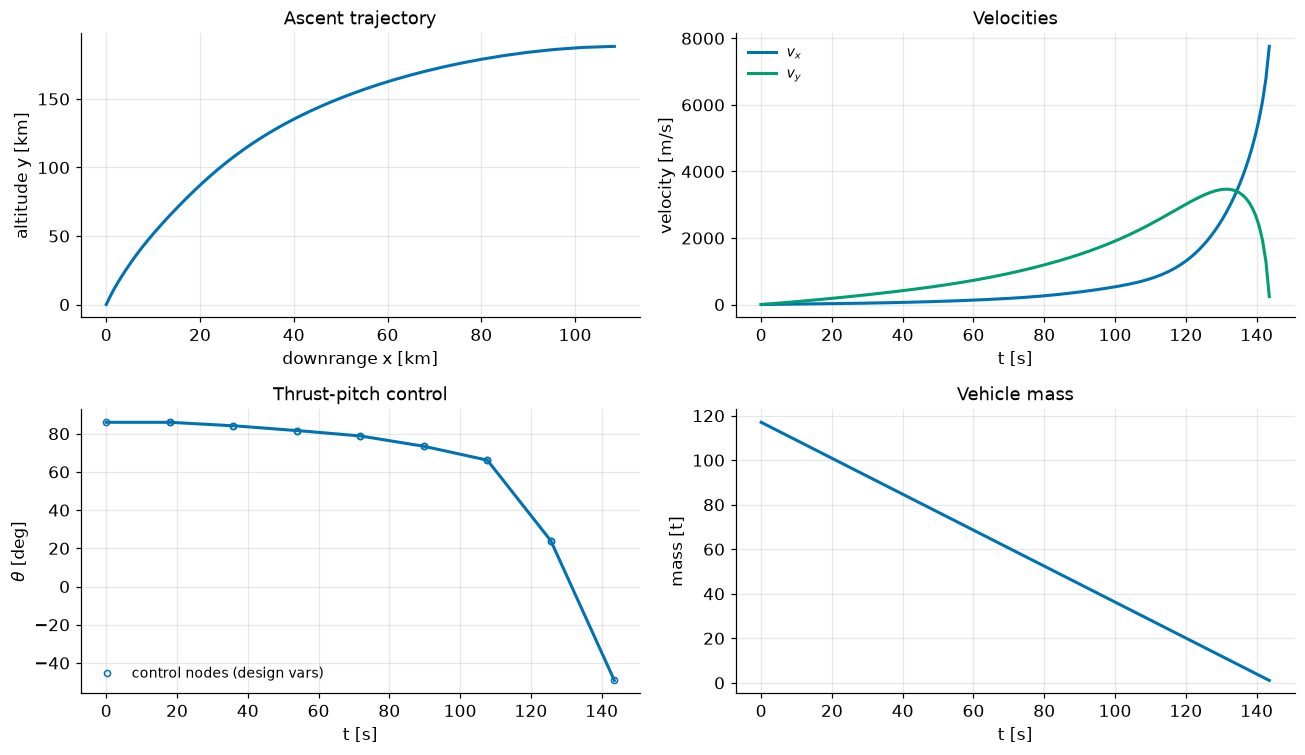

In [18]:
with quiet():
    sim = p_ssto.model.phase0.simulate(times_per_seg=20)
d = {k: sim.get_val(f'phase0.timeseries.{k}')[:, 0]
     for k in ('time', 'x', 'y', 'vx', 'vy', 'theta', 'm')}
t_nodes = p_ssto.get_val('phase0.timeseries.time')[:, 0]
th_nodes = p_ssto.get_val('phase0.timeseries.theta')[:, 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
ax = axes[0, 0]
ax.plot(d['x'] / 1e3, d['y'] / 1e3, color=COLORS['dymos'])
ax.set_xlabel('downrange x [km]'); ax.set_ylabel('altitude y [km]')
ax.set_title('Ascent trajectory')

ax = axes[0, 1]
ax.plot(d['time'], d['vx'], color=COLORS['dymos'], label=r'$v_x$')
ax.plot(d['time'], d['vy'], color=COLORS['secondary'], label=r'$v_y$')
ax.set_xlabel('t [s]'); ax.set_ylabel('velocity [m/s]')
ax.set_title('Velocities'); ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(d['time'], np.degrees(d['theta']), color=COLORS['dymos'])
ax.plot(t_nodes, np.degrees(th_nodes), 'o', ms=4, mfc='none',
        color=COLORS['dymos'], label='control nodes (design vars)')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [deg]')
ax.set_title('Thrust-pitch control'); ax.legend(fontsize=9)

ax = axes[1, 1]
ax.plot(d['time'], d['m'] / 1e3, color=COLORS['dymos'])
ax.set_xlabel('t [s]'); ax.set_ylabel('mass [t]')
ax.set_title('Vehicle mass')
fig.tight_layout()

---
## 6. Takeaways

1. **Multiple shooting = arcs + defects.** Arc initial states become design
   variables; continuity defects stitch the arcs; sensitivities propagate only
   across one arc, and the Jacobian breaks into staircase blocks.
2. **Two dymos routes**: a `Trajectory` of linked shooting phases (arcs =
   phases, each with its own integration, duration, ODE — or control
   structure; sections 2 and 3), or the compact `solve_segments='forward'`
   with an uncompressed grid (arcs = segments inside one phase, each
   implicitly integrated by a nested Newton solve; section 4).
3. **Structure beats refinement.** Giving the transcription the switching
   structure — two variable-length arcs with constant control — recovered the
   bang-bang solution to machine precision with a 7-variable NLP, where
   uniform refinement crawled. The structure itself comes from optimality
   conditions: Lecture 11.
4. **Multiple shooting scales to real models.** The interceptor climb —
   tabulated aero and propulsion, five states, path constraints — solved in
   about half a minute with the same arcs-and-defects structure as the
   brachistochrone.
5. **Single shooting on a real problem is expensive and fragile**: the SSTO
   capstone needed scaling, a duration bound, an ODE safeguard so every trial
   integration survives, and a propagation tolerance and control grid trimmed
   to the bare minimum — and still takes over a minute where collocation
   takes seconds.

**Lecture 10** takes the related localization idea further: no integrator at
all, with the dynamics imposed as sparse polynomial defect constraints. The
machinery of defects, sparsity, and scaling is already familiar.